In [1]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import rasterio.mask as rio_mask

In [2]:
data_path = Path(os.environ["DATA_PATH"])
ghsl_path = Path(os.environ["GHSL_PATH"])

In [3]:
bounds = (
    gpd.read_file(data_path / "lim_aumxl24/lim_aumxl24.shp")
    .to_crs("ESRI:54009")["geometry"]
    .item()
)

In [4]:
arr = []
for year in range(1975, 2021, 5):
    with rio.open(ghsl_path / "BUILT_100" / f"{year}.tif") as ds:
        data, transform = rio_mask.mask(ds, [bounds], crop=True, nodata=0)
        data = data.squeeze()
        arr.append(data)
        profile = ds.profile

arr = np.array(arr)

In [5]:
masked = (arr >= 0.2) * np.array(list(range(1975, 2021, 5)), dtype=np.float64).reshape(
    -1, 1, 1,
)
masked[masked == 0] = np.nan
masked = np.nanmin(masked, axis=0)

out = (
    (masked < 1990) * 1
    + ((masked >= 1990) & (masked < 2010)) * 2
    + (masked >= 2010) * 3
)

C:\Users\lain\AppData\Local\Temp\ipykernel_18584\1933906614.py:3: RuntimeWarning: All-NaN slice encountered
  masked = np.nanmin(masked, axis=0)


In [9]:
with rio.open(
    "./out.tif",
    "w",
    height=out.shape[0],
    width=out.shape[1],
    count=1,
    dtype="uint8",
    crs="ESRI:54009",
    transform=transform,
    nodata=0,
    driver="GTiff",
    compress="lzw",
) as dst:
    dst.write(out.astype(np.uint8), 1)

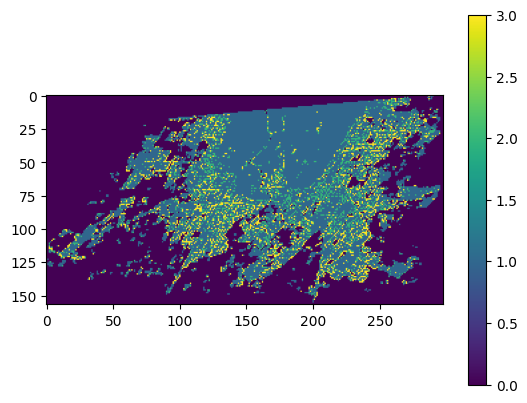

In [59]:
plt.imshow(out)
plt.colorbar()